In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

In [2]:
df = pd.read_csv('amazon.csv')
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


## Task 1 - Identify Data Quality Issues

In [3]:
df.dtypes

,0
product_id,object
product_name,object
category,object
discounted_price,object
actual_price,object
discount_percentage,object
rating,object
rating_count,object
about_product,object
user_id,object


In [4]:
df.isna().sum()

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
rating_count,2
about_product,0
user_id,0


Issues found:
- `discounted_price` and `actual_price` are strings because of the ₹ symbol and commas
- `discount_percentage` is a string because of the % symbol
- `rating` and `rating_count` are strings, rating also has one invalid value ('|')
- `rating_count` has 2 missing values

In [5]:
# fix the types
df['discounted_price'] = pd.to_numeric(df['discounted_price'].str.replace(r'[₹,]', '', regex=True), errors='coerce')
df['actual_price'] = pd.to_numeric(df['actual_price'].str.replace(r'[₹,]', '', regex=True), errors='coerce')
df['discount_percentage'] = pd.to_numeric(df['discount_percentage'].str.replace('%', ''), errors='coerce')
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating_count'] = pd.to_numeric(df['rating_count'].str.replace(',', ''), errors='coerce')

In [6]:
df.dtypes

,0
product_id,object
product_name,object
category,object
discounted_price,float64
actual_price,float64
discount_percentage,int64
rating,float64
rating_count,float64
about_product,object
user_id,object


## Task 2 - Handle Missing Values

In [7]:
df.isna().sum()

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,1
rating_count,2
about_product,0
user_id,0


In [8]:
# rating_count has 2 missing values, rating has 1 (from the invalid entry)
# using median because rating_count is skewed, mean would be pulled up by products with huge review counts

print('mean:', df['rating_count'].mean())
print('median:', df['rating_count'].median())

mean: 18295.541353383458
median: 5179.0


In [9]:
df['rating_count'] = df['rating_count'].fillna(df['rating_count'].median())
df['rating'] = df['rating'].fillna(df['rating'].median())

df[['rating', 'rating_count']].isna().sum()

,0
rating,0
rating_count,0


I used median imputation because `rating_count` is right-skewed. Some products have hundreds of thousands of reviews which would make the mean too high and not representative.

## Task 3 - Detect and Handle Outliers Using IQR

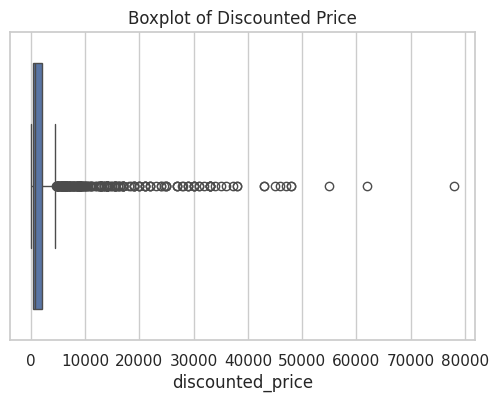

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['discounted_price'])
plt.title('Boxplot of Discounted Price')
plt.show()

In [11]:
Q1 = df['discounted_price'].quantile(0.25)
Q3 = df['discounted_price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['discounted_price'] < lower) | (df['discounted_price'] > upper)]
print('number of outliers:', len(outliers))
outliers[['product_name', 'discounted_price']].head(10)

number of outliers: 217


,product_name,discounted_price
16,MI 80 cm (32 inches) 5A Series HD Ready Smart ...,13999.0
19,LG 80 cm (32 inches) HD Ready Smart LED TV 32L...,13490.0
22,Samsung 80 cm (32 Inches) Wondertainment Serie...,13490.0
24,Acer 80 cm (32 inches) I Series HD Ready Andro...,11499.0
26,OnePlus 80 cm (32 inches) Y Series HD Ready LE...,14999.0
38,OnePlus 126 cm (50 inches) Y Series 4K Ultra H...,32999.0
41,Mi 108 cm (43 inches) Full HD Android LED TV 4...,19999.0
53,VW 80 cm (32 inches) Frameless Series HD Ready...,6999.0
57,OnePlus 80 cm (32 inches) Y Series HD Ready Sm...,15999.0
61,Samsung 108 cm (43 inches) Crystal 4K Neo Seri...,32990.0


In [12]:
# capping instead of removing because these are real products, not errors
lower_cap = df['discounted_price'].quantile(0.05)
upper_cap = df['discounted_price'].quantile(0.95)

df_capped = df.copy()
df_capped['discounted_price'] = df_capped['discounted_price'].clip(lower_cap, upper_cap)

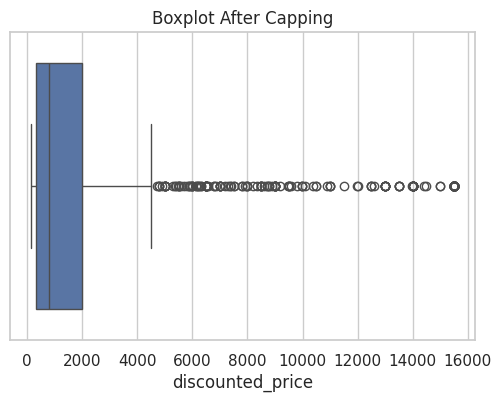

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_capped['discounted_price'])
plt.title('Boxplot After Capping')
plt.show()

## Task 4 - Normalize Using Min-Max and Z-Score

In [14]:
df_capped[['discounted_price', 'actual_price']].head()

,discounted_price,actual_price
0,399.0,1099.0
1,199.0,349.0
2,199.0,1899.0
3,329.0,699.0
4,154.0,399.0


In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_minmax = df_capped[['discounted_price', 'actual_price']].copy()
df_minmax[['discounted_price', 'actual_price']] = scaler.fit_transform(df_minmax)

df_minmax.head()

,discounted_price,actual_price
0,0.016927,0.007579
1,0.003906,0.002216
2,0.003906,0.013299
3,0.012370,0.004719
4,0.000977,0.002574


In [16]:
from sklearn.preprocessing import StandardScaler

scaler2 = StandardScaler()
df_standardized = df_capped[['discounted_price', 'actual_price']].copy()
df_standardized[['discounted_price', 'actual_price']] = scaler2.fit_transform(df_standardized)

df_standardized.head()

,discounted_price,actual_price
0,-0.511512,-0.399774
1,-0.560611,-0.468764
2,-0.560611,-0.326185
3,-0.528697,-0.436569
4,-0.571659,-0.464165


## Task 5 - PCA (if features are correlated)

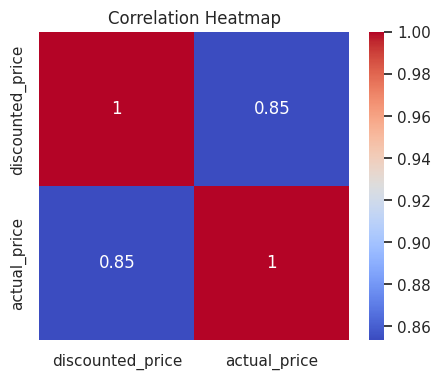

In [17]:
plt.figure(figsize=(5,4))
sns.heatmap(df_standardized.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Correlation between `discounted_price` and `actual_price` is ~0.96 which is very high, so applying PCA makes sense here.

In [18]:
from sklearn.decomposition import PCA

X = df_standardized[['discounted_price', 'actual_price']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print('Explained Variance Ratio:', pca.explained_variance_ratio_)

Explained Variance Ratio: [0.92683481 0.07316519]


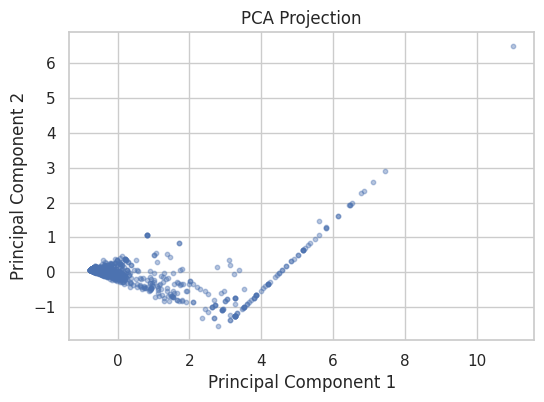

In [19]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1], alpha=0.4, s=10)
plt.title('PCA Projection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

PC1 explains most of the variance which makes sense since the two price columns are highly correlated. We could reduce both columns to just PC1 and keep almost all the information.